In [1]:
import torch 
import numpy as np 
import pandas as pd 
import torch.nn as nn 
import random 
import torch.nn.functional as F
from time import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

In [ ]:
class Linear_Classification:

    def __init__(self,X,y,classes,epochs,lr,reg_constant = None,reg_type = None):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
        self.net = nn.Linear(X.shape[1],classes)
        self.lr = lr 
        self.reg_constant = reg_constant
        self.reg_type = reg_type
        self.epochs = epochs
        self.criterion = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(
                    self.net.parameters(),
                    lr = self.lr 
                )

    def forward(self):
        return self.net(self.X)

    def softmax(self,logits):
        probabilities = F.softmax(logits, dim=-1)
        return probabilities
        

    def loss(self,y_pred,y):
        # Cross entropy loss 
        penalty = 0.0

        if self.reg_type == "L1":
            penalty = self.reg_constant * torch.sum(torch.abs(self.net.weight))

        elif self.reg_type == "L2":
            penalty = (self.reg_constant / 2) * torch.sum(self.net.weight**2)

        return self.criterion(y_pred,y) + penalty


    def fit(self):

        for _ in range(self.epochs):

            logits = self.forward()
            # y_pred = self.softmax(logits)
            loss = self.loss(logits,self.y)

            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

In [ ]:
# Generate 3 classes, 2 features
X, y = make_blobs(
    n_samples=300,
    centers=3,
    n_features=2,
    cluster_std=1.5,
    random_state=42
)

print("X shape:", X.shape)  # (300, 2)
print("y shape:", y.shape)  # (300,)
print("Classes:", np.unique(y))  # [0, 1, 2]

X shape: (300, 2)
y shape: (300,)
Classes: [0 1 2]


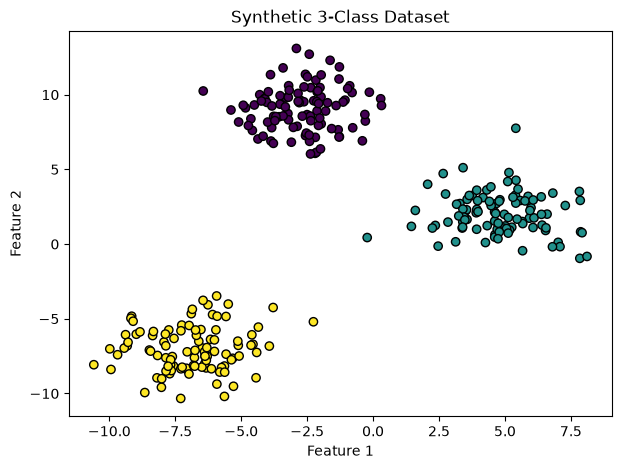

In [4]:
plt.figure(figsize=(7, 5))

plt.scatter(
    X[:, 0], X[:, 1],
    c=y,
    cmap="viridis",
    edgecolors="black"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic 3-Class Dataset")
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Linear Classification without Regularization

In [9]:
model = Linear_Classification(
    X_train,
    y_train,
    classes=3,
    epochs=1000,
    lr=0.01
)

model.fit()

print("Parametes W : ", model.net.weight)
print("Parameters b : ",model.net.bias)


logits = model.forward()  # Training data logits
probs = model.softmax(logits)

# Predict class with highest probability
y_pred = torch.argmax(probs, axis=1)

accuracy = (y_pred == model.y).float().mean()

print("Training accuracy:", accuracy)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_logits = model.net(X_test_tensor)
test_probs = model.softmax(test_logits)

test_pred = torch.argmax(test_probs, dim=1)

y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_accuracy = (test_pred == y_test_tensor).float().mean()

print("Test accuracy:", test_accuracy.item())

Parametes W :  Parameter containing:
tensor([[-0.6330,  0.4459],
        [ 0.6707, -0.0785],
        [-0.5000, -0.5557]], requires_grad=True)
Parameters b :  Parameter containing:
tensor([-0.7360,  0.4262,  0.6118], requires_grad=True)
Training accuracy: tensor(0.9958)
Test accuracy: 1.0


### Linear Classification with L1

In [10]:
model = Linear_Classification(
    X_train,
    y_train,
    classes=3,
    epochs=1000,
    lr=0.01,
    reg_constant=0.1,
    reg_type="L1"
)


model.fit()

print("Parametes W : ", model.net.weight)
print("Parameters b : ",model.net.bias)


logits = model.forward()  # Training data logits
probs = model.softmax(logits)

# Predict class with highest probability
y_pred = torch.argmax(probs, axis=1)

accuracy = (y_pred == model.y).float().mean()

print("Training accuracy:", accuracy)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_logits = model.net(X_test_tensor)
test_probs = model.softmax(test_logits)

test_pred = torch.argmax(test_probs, dim=1)

y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_accuracy = (test_pred == y_test_tensor).float().mean()

print("Test accuracy:", test_accuracy.item())

Parametes W :  Parameter containing:
tensor([[ 0.0008,  0.2447],
        [ 0.7677, -0.0010],
        [-0.0495, -0.2918]], requires_grad=True)
Parameters b :  Parameter containing:
tensor([ 0.2212,  0.2249, -0.3625], requires_grad=True)
Training accuracy: tensor(0.9958)
Test accuracy: 1.0


### Linear Classification with L2

In [11]:
model = Linear_Classification(
    X_train,
    y_train,
    classes=3,
    epochs=1000,
    lr=0.01,
    reg_constant=0.1,
    reg_type="L2"
)

model.fit()

print("Parametes W : ", model.net.weight)
print("Parameters b : ",model.net.bias)


logits = model.forward()  # Training data logits
probs = model.softmax(logits)

# Predict class with highest probability
y_pred = torch.argmax(probs, axis=1)

accuracy = (y_pred == model.y).float().mean()

print("Training accuracy:", accuracy)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

test_logits = model.net(X_test_tensor)
test_probs = model.softmax(test_logits)

test_pred = torch.argmax(test_probs, dim=1)

y_test_tensor = torch.tensor(y_test, dtype=torch.long)

test_accuracy = (test_pred == y_test_tensor).float().mean()

print("Test accuracy:", test_accuracy.item())

Parametes W :  Parameter containing:
tensor([[-0.3926,  0.4521],
        [ 0.4570,  0.1082],
        [-0.4229, -0.2560]], requires_grad=True)
Parameters b :  Parameter containing:
tensor([-0.1622,  0.3672, -0.3612], requires_grad=True)
Training accuracy: tensor(1.)
Test accuracy: 1.0
